# Mechanism discovery from a potential energy surface

POUNCE's `reaction_network` maps a smooth energy surface into its stable states (minima) and the transition states (saddles) between them, with barrier heights. `discopt.mkm.discover_mechanism` turns that into an mkm **spec**: each minimum becomes a surface state with `H` = its energy, and each connecting saddle becomes a reversible step `S_i <=> S_j` with forward `Ea` = the barrier (the reverse barrier follows from the thermodynamics automatically).

In [1]:
%matplotlib inline

## A model potential energy surface

A tilted symmetric quartic with four wells (near x = -2, -1, 1, 2) at distinct energies. Gradient and Hessian come from JAX autodiff.

In [2]:
import numpy as np, jax, jax.numpy as jnp
jax.config.update('jax_enable_x64', True)
import discopt.mkm as mk

def V(p):
    x, y = p[0], p[1]
    return (x**2 - 1.0)**2 * (x**2 - 4.0)**2 / 8.0 + 0.5*y**2 + 0.2*x
g = jax.grad(lambda p: V(jnp.asarray(p)))
h = jax.hessian(lambda p: V(jnp.asarray(p)))
fun  = lambda p: float(V(jnp.asarray(p)))
grad = lambda p: np.asarray(g(np.asarray(p, float)))
hess = lambda p: np.asarray(h(np.asarray(p, float)))

## Map the network and build a mechanism spec

In [3]:
rn, spec = mk.discover_mechanism(fun, np.array([0.0, 0.0]), grad=grad, hess=hess,
                                 A=1e13, T=500.0, n_states=6, seed=0)
print(rn.summary())

4 states, 3 transition states (minima:converged, ts:converged, 182 solves)
states:
  0: (-2.0054, +0.0000)  E=  -0.401  (global)
  1: (-1.0225, +0.0000)  E=  -0.202
  2: (+0.9780, +0.0000)  E=   0.198
  3: (+1.9943, +0.0000)  E=   0.399
barriers:
  state 1 <-> state 0  via TS E=   0.318   1->0:   0.521   0->1:   0.719
  state 3 <-> state 2  via TS E=   0.951   3->2:   0.551   2->3:   0.753
  state 2 <-> state 1  via TS E=   2.002   2->1:   1.804   1->2:   2.204


In [4]:
print('discovered states (H = PES energy):')
for a in spec['adsorbates']:
    print(f"  {a['name']}: H = {a['H']:+.3f}")
print('discovered steps (Ea = barrier):')
for r in spec['reactions']:
    print(f"  {r['equation']:14s}  Ea = {r['Ea']:.3f}")

discovered states (H = PES energy):
  S0: H = -0.401
  S1: H = -0.202
  S2: H = +0.198
  S3: H = +0.399
discovered steps (Ea = barrier):
  S1 <=> S0       Ea = 0.521
  S3 <=> S2       Ea = 0.551
  S2 <=> S1       Ea = 1.804


## The discovered mechanism as a model: free-energy diagram + structure

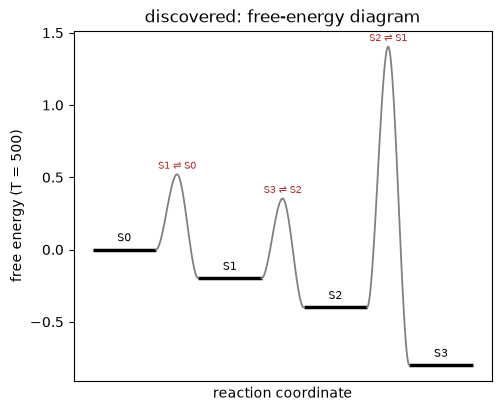

In [5]:
m, _ = mk.from_spec(spec)
ax = mk.energy_diagram(m)


In [6]:
from discopt.mkm.analysis import stoichiometry as st
print('independent reactions:', st.n_independent_reactions(m), 'of', len(m.reactions))
print('site-balanced       :', st.check_site_balance(m) == [])

independent reactions: 3 of 3
site-balanced       : True


## From skeleton to kinetics

`reaction_network` gives the mechanism *skeleton with energetics* — exactly the species energies and barriers a microkinetic model needs. To make it a solvable kinetic model, couple one or more states to a gas phase (add adsorption/desorption steps with gas species) in the returned spec, then `solve` it. The energy diagram above is the manual `energy_diagram` figure produced automatically from the PES.